<a href="https://colab.research.google.com/github/harishkotalwar5-beep/Java-Practicals/blob/main/Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data = pd.read_csv("train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
cabin_list = ['A', 'B', 'C', 'D', 'E', 'T', 'G', 'Unknown']

In [37]:
def search_substring(big_string, substring_list):
  for substring  in substring_list:
    if substring in big_string:
      return substring
  return substring_list[-1]

In [38]:
import re

A = "my name is Harish"
B = re.search("Harish", A)

print(B.group())

Harish


In [39]:
def get_title(string): #get title is a function it has a parameter string that string contains passenger name
  import re
  regex=re.compile(r'Mr|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countless|Dona|mme|Ms|Miss|Master',re.IGNORECASE)
  results = regex.search(string)
  if results != None:
    return(results.group().lower())
  else:
    return(str(np.nan))

In [40]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [41]:
data['Deck'] = data['Cabin'].map(lambda x: search_substring(str(x), cabin_list))
#test_set['Deck'] = test_set['cabin'].map(lambda x: search_substring(str(x), cabin_list))
# delete the cabin feature
data.drop('Cabin', axis=1, inplace=True)


In [42]:
data['Title']=data['Name'].apply(get_title)
data["Title"]= data['Title'].map(title_dictionary)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [43]:
data.drop('Name', axis=1, inplace=True)
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Unknown,Mr


In [44]:
data.drop('Ticket', axis=1, inplace=True)
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


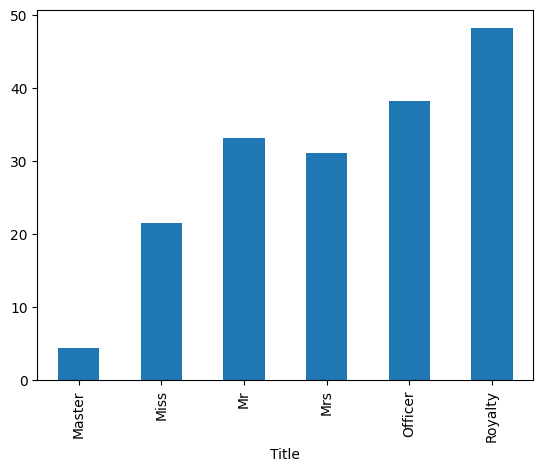

In [45]:
means_title = data.groupby('Title')['Age'].mean()
mk = data.groupby('Title')['Age'].mean().plot(kind='bar')

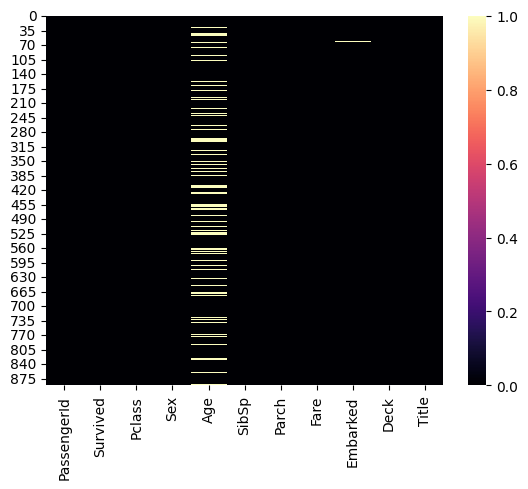

In [46]:
sns.heatmap(data.isnull(), cmap='magma')
plt.show()

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   Deck         891 non-null    object 
 10  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


<Axes: xlabel='Embarked'>

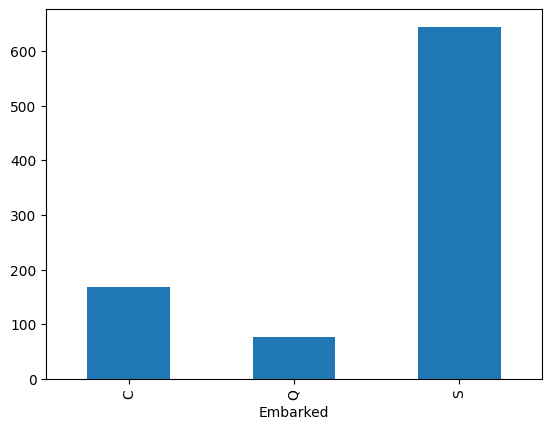

In [50]:
data.groupby('Embarked').size().plot(kind='bar')

In [52]:
data['Embarked'].fillna('S', inplace =True)
data.head()

/tmp/ipykernel_14108/2323613445.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna('S', inplace =True)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Unknown,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,Unknown,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,Unknown,Mr


/tmp/ipykernel_14108/1047457177.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table("Survived", parch_intervals, 'Sex').plot(kind='bar')


<Axes: xlabel='Parch'>

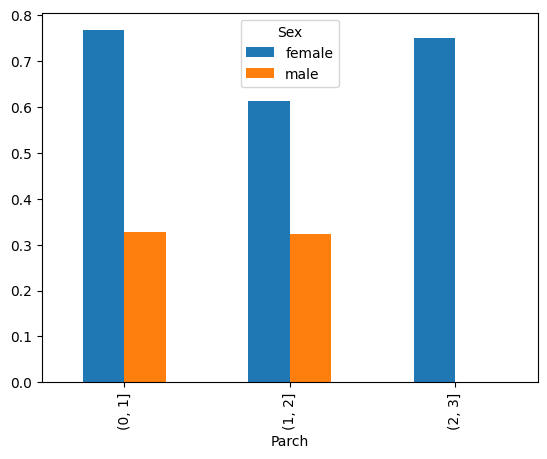

In [54]:
parch_intervals = pd.cut(data['Parch'], (0,1,2,3))
data.pivot_table("Survived", parch_intervals, 'Sex').plot(kind='bar')

/tmp/ipykernel_14108/3568844907.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table("Survived", parch_intervals, 'Sex').plot(kind='bar')


<Axes: xlabel='SibSp'>

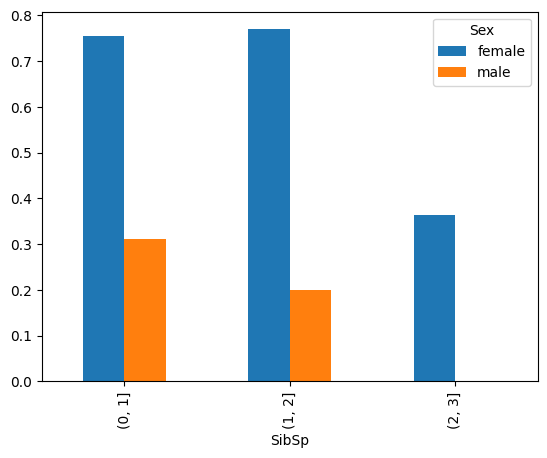

In [57]:
parch_intervals = pd.cut(data['SibSp'], (0,1,2,3))
data.pivot_table("Survived", parch_intervals, 'Sex').plot(kind='bar')

In [59]:
data['Family Size'] = data['Parch'] + data['SibSp']
data.drop('Parch', axis=1, inplace=True)
data.drop('SibSp', axis=1, inplace=True)
data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,7.2500,S,Unknown,Mr,1
1,2,1,1,female,38.0,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,7.9250,S,Unknown,Miss,0
3,4,1,1,female,35.0,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,8.0500,S,Unknown,Mr,0
